In [479]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
import gradio as gr
import pickle
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [480]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akshatgupta7/crop-yield-in-indian-states-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-yield-in-indian-states-dataset' dataset.
Path to dataset files: /kaggle/input/crop-yield-in-indian-states-dataset


In [481]:
data=pd.read_csv(os.path.join(path+'/crop_yield.csv'))

In [482]:
data2=data

In [483]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [484]:
data['Crop'].value_counts()

,count
Crop,
Rice,1197
Maize,975
Moong(Green Gram),740
Urad,733
Groundnut,725
Sesamum,685
Potato,628
Sugarcane,605
Wheat,545


In [485]:
data['Season'].value_counts()

,count
Season,
Kharif,8232
Rabi,5742
Whole Year,3717
Summer,1195
Autumn,414
Winter,389


In [486]:
data['State'].value_counts()

,count
State,
Karnataka,1432
Andhra Pradesh,1266
West Bengal,1094
Chhattisgarh,915
Bihar,896
Madhya Pradesh,845
Uttar Pradesh,825
Tamil Nadu,822
Gujarat,817


In [487]:
encoder1=OrdinalEncoder()
encoder2=OneHotEncoder(drop='first',sparse_output=False)

In [488]:
data[['Crop','State']]=encoder1.fit_transform(data[['Crop','State']])

In [489]:
data.sample(5)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
17287,26.0,2019,Kharif,29.0,12434.0,166211,1733.4,2135663.84,4600.58,11.719375
14961,42.0,2016,Kharif,9.0,5.0,1,1373.9,766.25,1.75,0.125000
8761,51.0,2003,Whole Year,27.0,887.0,1604,1075.6,87795.26,212.88,1.823143
15470,38.0,2017,Kharif,4.0,7274.0,1651,1124.5,1145218.56,2764.12,0.194667
8360,1.0,2003,Kharif,3.0,38855.0,48100,1353.9,3845867.90,9325.20,1.206316


In [490]:
encoded=encoder2.fit_transform(data[['Season']])

In [491]:
encoded=pd.DataFrame(encoded,columns=encoder2.get_feature_names_out())

In [492]:
data.drop('Season',inplace=True,axis=1)

In [493]:
data=pd.concat([data,encoded],axis=1)

In [494]:
data.sample(5)

,Crop,Crop_Year,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Season_Kharif,Season_Rabi,Season_Summer,Season_Whole Year,Season_Winter
9198,40.0,2004,28.0,281464.0,537876,1219.6,30493809.76,59107.44,1.592308,1.0,0.0,0.0,0.0,0.0
15587,8.0,2017,11.0,153.0,57,1165.7,24088.32,58.14,0.483333,1.0,0.0,0.0,0.0,0.0
15957,53.0,2017,28.0,330401.0,929884,1475.8,52018333.44,125552.38,2.100769,0.0,1.0,0.0,0.0,0.0
11511,44.0,2010,4.0,158948.0,33299,1283.1,26402852.28,38147.52,0.213889,1.0,0.0,0.0,0.0,0.0
1125,40.0,2002,13.0,112438.0,233217,2511.2,10644505.46,28109.50,2.130769,0.0,0.0,0.0,0.0,0.0


In [495]:
data['Fertilizer_Usage']=data['Fertilizer']/data['Area']
data['Pesticide_Usage']=data['Pesticide']/data['Area']
data['Rain_Fert_Interaction']=data['Annual_Rainfall']*data['Fertilizer_Usage']

In [496]:
data.replace([np.inf, -np.inf],0,inplace=True)

In [497]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   19689 non-null  float64
 1   Crop_Year              19689 non-null  int64  
 2   State                  19689 non-null  float64
 3   Area                   19689 non-null  float64
 4   Production             19689 non-null  int64  
 5   Annual_Rainfall        19689 non-null  float64
 6   Fertilizer             19689 non-null  float64
 7   Pesticide              19689 non-null  float64
 8   Yield                  19689 non-null  float64
 9   Season_Kharif          19689 non-null  float64
 10  Season_Rabi            19689 non-null  float64
 11  Season_Summer          19689 non-null  float64
 12  Season_Whole Year      19689 non-null  float64
 13  Season_Winter          19689 non-null  float64
 14  Fertilizer_Usage       19689 non-null  float64
 15  Pe

In [498]:
scaler=StandardScaler()

In [499]:
data[['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Fertilizer_Usage','Pesticide_Usage','Rain_Fert_Interaction']]=scaler.fit_transform(data[['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Fertilizer_Usage','Pesticide_Usage','Rain_Fert_Interaction']])

In [500]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   19689 non-null  float64
 1   Crop_Year              19689 non-null  int64  
 2   State                  19689 non-null  float64
 3   Area                   19689 non-null  float64
 4   Production             19689 non-null  float64
 5   Annual_Rainfall        19689 non-null  float64
 6   Fertilizer             19689 non-null  float64
 7   Pesticide              19689 non-null  float64
 8   Yield                  19689 non-null  float64
 9   Season_Kharif          19689 non-null  float64
 10  Season_Rabi            19689 non-null  float64
 11  Season_Summer          19689 non-null  float64
 12  Season_Whole Year      19689 non-null  float64
 13  Season_Winter          19689 non-null  float64
 14  Fertilizer_Usage       19689 non-null  float64
 15  Pe

In [501]:
y=data['Yield']
x=data.drop('Yield',axis=1)

In [502]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [503]:
model1=RandomForestRegressor(max_depth=20,min_samples_split=2,n_estimators=100,random_state=42)

In [504]:
model1.fit(x_train,y_train)

RandomForestRegressor(max_depth=20, random_state=42)

In [505]:
y_pred=model1.predict(x_test)

In [506]:
mean_squared_error(y_test,y_pred)

75727.79520517058

In [507]:
mean_absolute_error(y_test,y_pred)

10.76907663750985

In [508]:
r2_score(y_test,y_pred)

0.9054867355934058

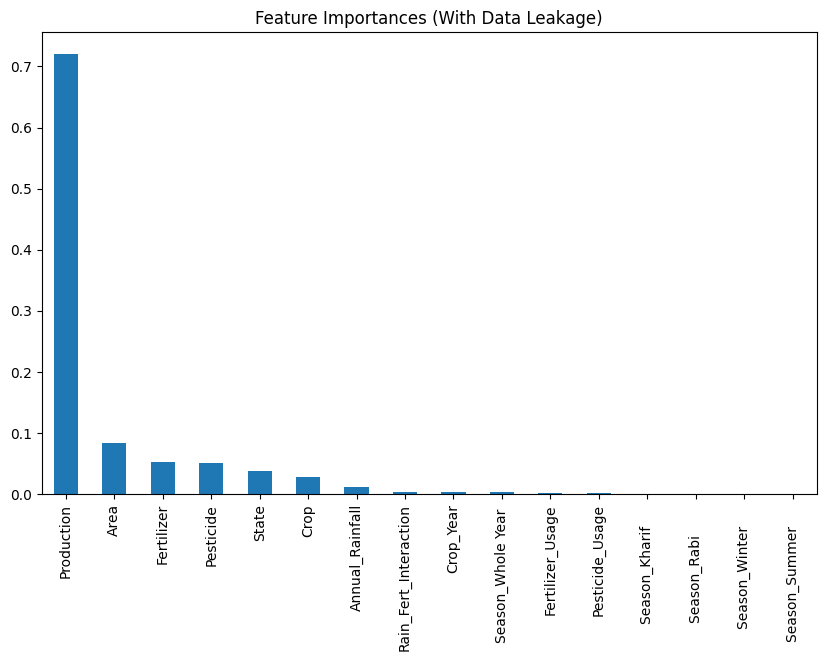

Top 3 Features: ['Production', 'Area', 'Fertilizer']


In [509]:
importances = pd.Series(model1.feature_importances_, index=x.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Feature Importances (With Data Leakage)')
plt.show()
print("Top 3 Features:", importances.head(3).index.tolist())

In [510]:
x=x.drop(['Production','Area'],axis=1)

In [511]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [512]:
model2=RandomForestRegressor(max_depth=20,n_estimators=100,random_state=42)

In [513]:
model2.fit(x_train,y_train)

RandomForestRegressor(max_depth=20, random_state=42)

In [514]:
y_pred=model2.predict(x_test)

In [515]:
r2_score(y_test,y_pred)

0.9752443568232942

In [516]:
mean_squared_error(y_test,y_pred)

19835.20819461876

In [517]:
mean_absolute_error(y_test,y_pred)

11.148433184084782

In [ ]:
!pip install gradio -q

In [518]:

def predict_yield(crop_name, state_name, crop_year, annual_rainfall, fertilizer, pesticide,
                  season_kharif, season_rabi, season_summer, season_whole_year, season_winter):
    cat_df=pd.DataFrame([[crop_name,state_name]],columns=['Crop','State'])
    cat_encoded=encoder1.transform(cat_df)

    area_val = 1.0 # Assuming unit area for a 'per hectare' style prediction if area is unknown
    fert_usage = fertilizer / area_val
    pest_usage = pesticide / area_val
    rain_fert = annual_rainfall * fert_usage
    raw_features = pd.DataFrame([[
        cat_encoded[0][0], crop_year, cat_encoded[0][1],
        annual_rainfall, fertilizer, pesticide,
        float(season_kharif), float(season_rabi), float(season_summer),
        float(season_whole_year), float(season_winter),
        fert_usage, pest_usage, rain_fert
    ]], columns=x.columns)
    cols_to_scale=['Annual_Rainfall','Fertilizer','Pesticide','Fertilizer_Usage','Pesticide_Usage','Rain_Fert_Interaction']
    prediction = model2.predict(raw_features)
    return f"Predicted Yield: {prediction[0]:.4f}"

# Get lists for dropdowns
crops = sorted(data_raw['Crop'].unique().tolist()) if 'data_raw' in locals() else sorted(encoder1.categories_[0].tolist())
states = sorted(data_raw['State'].unique().tolist()) if 'data_raw' in locals() else sorted(encoder1.categories_[1].tolist())

interface = gr.Interface(
    fn=predict_yield,
    inputs=[
        gr.Dropdown(choices=crops, label="Crop"),
        gr.Dropdown(choices=states, label="State"),
        gr.Number(label="Year", value=2024),
        gr.Number(label="Annual Rainfall (mm)", value=1000),
        gr.Number(label="Fertilizer Amount", value=500000),
        gr.Number(label="Pesticide Amount", value=500),
        gr.Checkbox(label="Is Kharif?"),
        gr.Checkbox(label="Is Rabi?"),
        gr.Checkbox(label="Is Summer?"),
        gr.Checkbox(label="Is Whole Year?"),
        gr.Checkbox(label="Is Winter?")
    ],
    outputs="text",
    title="Crop Yield Prediction Interface",
    description="Enter environmental and agricultural factors to predict crop yield."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7d335f55fae755e4e6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Building Pipeline**


*   Combining Preprocessing and model



In [519]:
data2['Fertilizer_Usage']=data2['Fertilizer']/data2['Area']
data2['Pesticide_Usage']=data2['Pesticide']/data2['Area']
data2['Rain_Fert_Interaction']=data2['Annual_Rainfall']*data2['Fertilizer_Usage']
data2.replace([np.inf,-np.inf],0,inplace=True)

In [520]:
x=data2.drop(['Yield','Production','Area'],axis=1)
y=data2['Yield']

In [521]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [522]:
cat_cols=['Crop','State']
num_cols=[col for col in x_train.columns if col not in cat_cols]
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [523]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(max_depth=20, n_estimators=100, random_state=42))
])

In [524]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Crop', 'State']),
                                                 ('num', StandardScaler(),
                                                  ['Crop_Year',
                                                   'Annual_Rainfall',
                                                   'Fertilizer', 'Pesticide',
                                                   'Fertilizer_Usage',
                                                   'Pesticide_Usage',
                                                   'Rain_Fert_Interaction'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, random_state=42))])

In [525]:
y_pred=pipeline.predict(x_test)

In [526]:
r2_score(y_test,y_pred)

0.9765956634297805

In [527]:
mean_squared_error(y_test,y_pred)

18752.487471788187

In [528]:
mean_absolute_error(y_test,y_pred)

10.963231316049626

In [529]:
with open('yield_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)